
**Lab 5 Mega Test**

Topics from Lab 1, 2, 3, 4: preprocessing → visualization → linear regression

**Time: 60 | Total: 100 marks**


Allowed: pandas, numpy, matplotlib/seaborn, sklearn


Rule: Write clear code with short comments. Show outputs (tables/plots).

# Dataset(Provided)
File: employee_salary.csv

Goal: Predict Salary from features (includes at least one categorical column and missing/sentinel values).

## Part A — Data Understanding + Preprocessing (Lab 1, 2) [40 marks]

### Q1. Load and understand the dataset [10]

Do the following and show the output:

1) Show the **first 5 rows** of the dataset.  
2) Show the **shape** of the dataset (rows, columns).  
3) Show the **data types** of each column.  
4) Show **how many missing values** exist per column.

### Q2. Clean missing and bad values [15]
The dataset contains missing values and may contain “sentinel” values (e.g. `"NA"`, `"?"`).

1) Detect and convert any sentinel/bad values to real missing values.  
2) Fill missing values using this rule:
- Numeric columns → fill using **mean**
- Categorical columns → fill using `"Not Available"`
3) After cleaning, show missing values per column again to prove it worked.

### Q3. Convert categorical to numeric (One-hot encoding) [15]
1) One-hot encode the categorical column(s) (e.g., `Education_Level`).  
2) Ensure the encoded columns are **0/1 numeric** (not True/False).  
3) Create:
- **X** = all input features
- **y** = target column

4) Show:
- shape of `X` and `y`
- data types of `X`

5) Explain: If you think any feature is not related to the Salary

# ***Q1. Load and understand the dataset [10]***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df=pd.read_csv('employee_salary.csv')
#1
df.head()

,Employee_ID,Age,Education_Level,Years_Experience,Department,Performance_Score,Training_Hours,Salary
0,1,25,Bachelor,2,IT,78,20,45000
1,2,30,Master,5,Finance,85,35,62000
2,3,28,Bachelor,3,HR,80,NaN,52000
3,4,35,PhD,10,IT,92,40,90000
4,5,40,Master,12,Finance,88,38,95000


In [ ]:
#2
df.shape

(20, 8)

In [ ]:
#3
df.dtypes

,0
Employee_ID,int64
Age,int64
Education_Level,object
Years_Experience,int64
Department,object
Performance_Score,int64
Training_Hours,object
Salary,int64


In [ ]:
#4
df.isnull().sum()

,0
Employee_ID,0
Age,0
Education_Level,1
Years_Experience,0
Department,0
Performance_Score,0
Training_Hours,3
Salary,0


# ***Q2. Clean missing and bad values [15]***

In [ ]:
#1
df.replace([-99999, "NA", "?", "na"], np.nan, inplace=True)

In [ ]:
df['Training_Hours']=df['Training_Hours'].replace(np.nan,'0')

In [ ]:
df['Training_Hours']=df['Training_Hours'].astype(int)

In [ ]:
#2
num_cols=df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)
cat_cols=df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna('Not Available', inplace=True)

In [ ]:
#3
df.isnull().sum()

,0
Employee_ID,0
Age,0
Education_Level,0
Years_Experience,0
Department,0
Performance_Score,0
Training_Hours,0
Salary,0


# ***Q3. Convert categorical to numeric (One-hot encoding) [15]***

In [ ]:
#1 and 2
df_encoder = pd.get_dummies(df,columns=cat_cols,dtype=int)
df_encoder.head()

,Employee_ID,Age,Years_Experience,Performance_Score,Training_Hours,Salary,Education_Level_Bachelor,Education_Level_Master,Education_Level_Not Available,Education_Level_PhD,Department_Finance,Department_HR,Department_IT,Department_Marketing
0,1,25,2,78,20,45000,1,0,0,0,0,0,1,0
1,2,30,5,85,35,62000,0,1,0,0,1,0,0,0
2,3,28,3,80,0,52000,1,0,0,0,0,1,0,0
3,4,35,10,92,40,90000,0,0,0,1,0,0,1,0
4,5,40,12,88,38,95000,0,1,0,0,1,0,0,0


In [ ]:
#3
X = df_encoder.drop('Salary',axis=1)
y = df_encoder['Salary']

In [ ]:
#4
print(X.shape)
print(y.shape)

print(X.dtypes)

(20, 13)
(20,)
Employee_ID                      int64
Age                              int64
Years_Experience                 int64
Performance_Score                int64
Training_Hours                   int64
Education_Level_Bachelor         int64
Education_Level_Master           int64
Education_Level_Not Available    int64
Education_Level_PhD              int64
Department_Finance               int64
Department_HR                    int64
Department_IT                    int64
Department_Marketing             int64
dtype: object


In [ ]:
#5.Age  and Employee_ID not related to Salary

## Part B — Statistics + Visualization (Lab 3) [25 marks]

### Q4. Summary statistics [10]
For **`Years_Experience`**, **`Performance_Score`** and **`Salary`**, compute and show:
- mean, median, standard deviation  


### Q5. Visualization  [15]
Create plots (must include title + labeled axes):
- Histogram or KDE plot of `Salary`
- Scatter plot of `Years_Experience` vs `Salary`
- Pie plot of Education_Level

# ***Q4. Summary statistics [10]***

In [ ]:
Years_Experience=df['Years_Experience']
Performance_Score =df['Performance_Score']
Salary =df['Salary']

print('mean of Years_Experience:',Years_Experience.mean())
print('median of Years_Experience:',Years_Experience.median())
print('standard deviation of Years_Experience:',Years_Experience.std())

print('mean of Performance_Score :',Performance_Score .mean())
print('median of Performance_Score :',Performance_Score .median())
print('standard deviation of Performance_Score :',Performance_Score .std())

print('mean of Salary :',Salary .mean())
print('median of Salary :',Salary .median())
print('standard deviation of Salary :',Salary .std())

mean of Years_Experience: 7.25
median of Years_Experience: 6.5
standard deviation of Years_Experience: 4.314906841709515
mean of Performance_Score : 83.5
median of Performance_Score : 83.5
standard deviation of Performance_Score : 6.6213371204884215
mean of Salary : 70400.0
median of Salary : 66000.0
standard deviation of Salary : 21206.751655769294


# ***Q5. Visualization [15]***

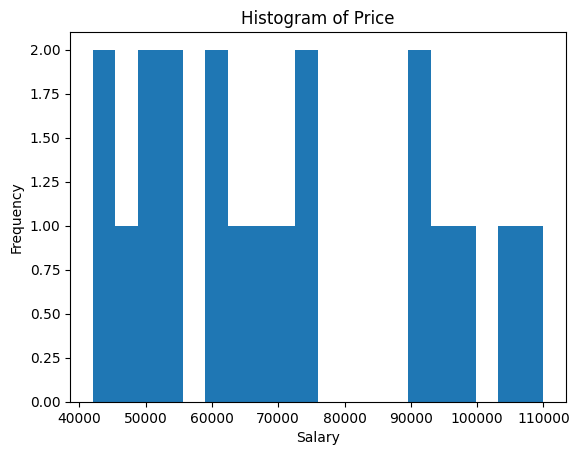

In [ ]:
#Histogram or KDE plot of Salary
plt.hist(Salary,bins=20)
plt.title('Histogram of Price')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

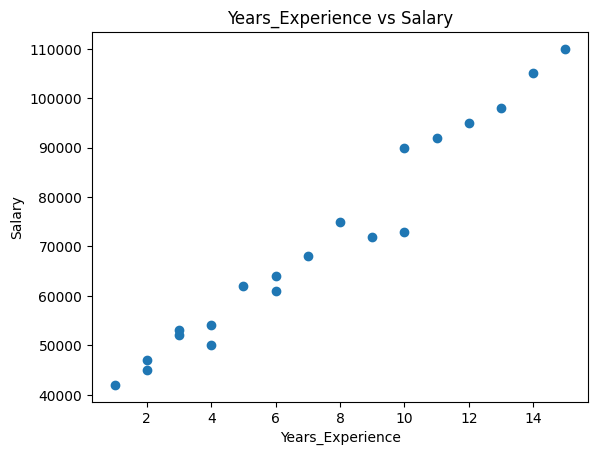

In [ ]:
#Scatter plot of Years_Experience vs Salary
plt.scatter(df["Years_Experience"], df["Salary"])
plt.title("Years_Experience vs Salary")
plt.xlabel("Years_Experience")
plt.ylabel("Salary")
plt.show()

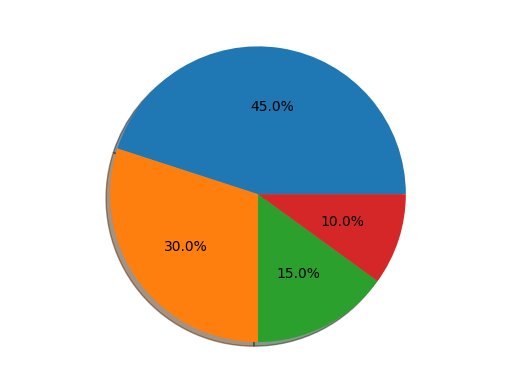

In [ ]:
val=df['Education_Level'].value_counts()
plt.axis('equal')
plt.pie(val, shadow=True, autopct='%1.1f%%', radius=1)
plt.show()

## Part C — Machine Learning Model (Lab 4: Linear Regression) [25 marks]

### Q7. Feature Scaling [10]

Before training the model, scale the **numeric features in X** using **two different scaling techniques separately**:

1. **Min–Max Normalization**
2. **Standardization (Z-score)**

For **each scaling method**, perform the following:

- Apply the scaling technique to the numeric features.
- Display the **first few rows** of the transformed dataset.
- Write **1–2 short comment lines** explaining:
  - how the scaling method transforms the data, and  
  - why feature scaling is useful for machine learning models.


### Q8. Linear Regression Model Training [15]

Using **each scaled dataset (Min–Max and Standardized)**:

1. Split the dataset into **training and testing sets (85% training, 15% testing)**.
2. Train a **Linear Regression model** using the training data.
3. Display the following model parameters:
   - **Intercept (bias)**
   - **Coefficients (weights)** for each feature.

# ***Q7. Feature Scaling [10]***

In [ ]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [ ]:
#Min–Max Normalization
numeric_cols = X.select_dtypes(include=['number']).columns
scaler = MinMaxScaler()
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

In [ ]:
X_scaled

,Employee_ID,Age,Years_Experience,Performance_Score,Training_Hours,Education_Level_Bachelor,Education_Level_Master,Education_Level_Not Available,Education_Level_PhD,Department_Finance,Department_HR,Department_IT,Department_Marketing
0,0.000000,0.047619,0.071429,0.32,0.476190,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.052632,0.285714,0.285714,0.60,0.833333,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.105263,0.190476,0.142857,0.40,0.000000,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.157895,0.523810,0.642857,0.88,0.952381,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.210526,0.761905,0.785714,0.72,0.904762,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
5,0.263158,0.238095,0.214286,0.24,0.523810,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
6,0.315789,0.333333,0.357143,0.48,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7,0.368421,0.095238,0.071429,0.20,0.428571,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,0.421053,0.666667,0.714286,0.80,0.857143,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
9,0.473684,0.142857,0.142857,0.36,0.571429,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
#StandardScaler
ss=StandardScaler()
X_ss = X.copy()
X_ss[numeric_cols] = ss.fit_transform(X[numeric_cols])

In [ ]:
X_ss

,Employee_ID,Age,Years_Experience,Performance_Score,Training_Hours,Education_Level_Bachelor,Education_Level_Master,Education_Level_Not Available,Education_Level_PhD,Department_Finance,Department_HR,Department_IT,Department_Marketing
0,-1.647509,-1.365416,-1.248320,-0.852227,-0.247601,1.105542,-0.654654,-0.333333,-0.420084,-0.654654,-0.5,1.527525,-0.5
1,-1.474087,-0.527737,-0.534994,0.232425,0.828927,-0.904534,1.527525,-0.333333,-0.420084,1.527525,-0.5,-0.654654,-0.5
2,-1.300665,-0.862809,-1.010545,-0.542326,-1.682972,1.105542,-0.654654,-0.333333,-0.420084,-0.654654,2.0,-0.654654,-0.5
3,-1.127243,0.309941,0.653882,1.317078,1.187769,-0.904534,-0.654654,-0.333333,2.380476,-0.654654,-0.5,1.527525,-0.5
4,-0.953821,1.147619,1.129433,0.697276,1.044232,-0.904534,1.527525,-0.333333,-0.420084,1.527525,-0.5,-0.654654,-0.5
5,-0.780399,-0.695273,-0.772770,-1.162127,-0.104064,-0.904534,-0.654654,3.000000,-0.420084,-0.654654,2.0,-0.654654,-0.5
6,-0.606977,-0.360202,-0.297219,-0.232425,-1.682972,1.105542,-0.654654,-0.333333,-0.420084,-0.654654,-0.5,-0.654654,2.0
7,-0.433555,-1.197880,-1.248320,-1.317078,-0.391139,1.105542,-0.654654,-0.333333,-0.420084,-0.654654,-0.5,1.527525,-0.5
8,-0.260133,0.812548,0.891657,1.007177,0.900695,-0.904534,1.527525,-0.333333,-0.420084,1.527525,-0.5,-0.654654,-0.5
9,-0.086711,-1.030344,-1.010545,-0.697276,0.039473,1.105542,-0.654654,-0.333333,-0.420084,-0.654654,-0.5,-0.654654,2.0


# ***Q8. Linear Regression Model Training [15]***

#MinMax

In [ ]:
from sklearn.model_selection import train_test_split as tts

In [ ]:
x_train,x_test,y_train,y_test=tts(X_scaled,y,test_size=0.15,random_state=45)

In [ ]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()

In [ ]:
reg.fit(x_train,y_train)

LinearRegression()

In [ ]:
reg.score(x_test,y_test)

0.6574194760530883

In [ ]:
reg.intercept_

np.float64(33925.38763414515)

In [ ]:
reg.coef_

array([ -964.46320615, 34923.31566117, 29887.32011407,  8310.39799178,
        8841.02115028,  2245.34485913, -3095.71619823, -3224.00151791,
        4074.37285701,   188.93545747,   -53.81701729,  -850.13590492,
         715.01746473])

In [ ]:
#Standardized
x_train1,x_test1,y_train1,y_test1=tts(X_ss,y,test_size=0.15,random_state=45)

In [ ]:
lr=LinearRegression()

In [ ]:
lr.fit(x_train1,y_train1)

LinearRegression()

In [ ]:
lr.score(x_test1,y_test1)

0.6574194760530856

In [ ]:
lr.intercept_

np.float64(71730.47497512716)

In [ ]:
lr.coef_

array([-2.92703481e+02,  9.92633320e+03,  8.97825975e+03,  2.14530634e+03,
        2.93304712e+03,  1.01758686e+03, -1.51024946e+03, -1.02717595e+03,
        1.38345700e+03,  1.07054084e+02, -3.65652455e+00, -3.69108233e+02,
        3.03877268e+02])

## Part D - Submission [10 marks]
Submit notebook as: **`Lab5_E2_Name_ID_Section.ipynb`**  
Notebook must run from top to bottom without errors.